In [5]:
import pandas as pd

df = pd.read_csv("../data/training/normal/session_20260216_212407.csv")

df.head()

,t_s,sensor_id,vx_um_s,vy_um_s,vz_um_s,dx_um,dy_um,dz_um
0,0.106809,0,8516.0,3091.0,3128.0,0.000000,0.000000,0.000000
1,0.108141,1,5298.0,5792.0,2867.0,0.000000,0.000000,0.000000
2,0.113047,0,8739.0,3159.0,3438.0,52.787245,19.120271,20.086992
3,0.114365,1,5298.0,5792.0,2867.0,32.345921,35.361943,17.503918
4,0.119579,0,8739.0,3159.0,3438.0,107.755058,38.989460,41.724887


In [6]:
print(df.columns)

Index(['t_s', 'sensor_id', 'vx_um_s', 'vy_um_s', 'vz_um_s', 'dx_um', 'dy_um',
       'dz_um'],
      dtype='str')


In [7]:
sensor0 = df[df["sensor_id"] == 0]

sensor0.head()

,t_s,sensor_id,vx_um_s,vy_um_s,vz_um_s,dx_um,dy_um,dz_um
0,0.106809,0,8516.0,3091.0,3128.0,0.000000,0.000000,0.000000
2,0.113047,0,8739.0,3159.0,3438.0,52.787245,19.120271,20.086992
4,0.119579,0,8739.0,3159.0,3438.0,107.755058,38.989460,41.724887
6,0.126550,0,8739.0,3159.0,3438.0,165.431541,59.837801,64.428146
8,0.133071,0,8951.0,3210.0,3524.0,218.820349,79.054262,85.452654


Matplotlib is building the font cache; this may take a moment.


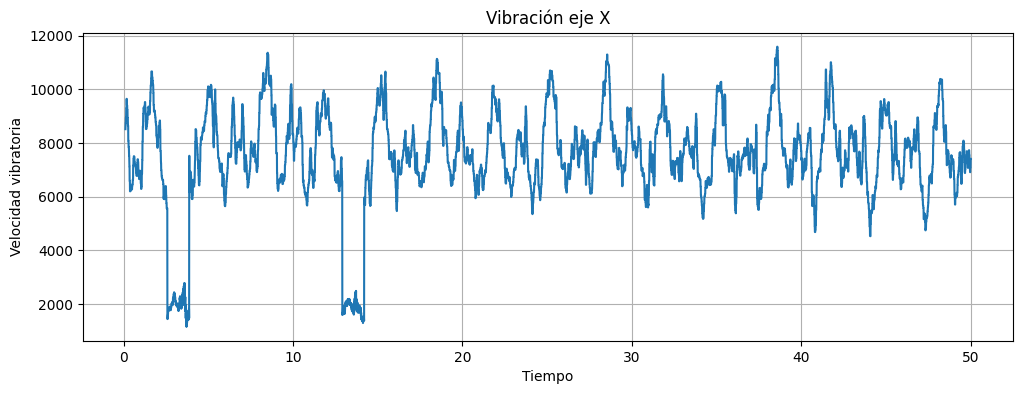

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.plot(
    sensor0["t_s"],
    sensor0["vx_um_s"]
)

plt.title("Vibración eje X")
plt.xlabel("Tiempo")
plt.ylabel("Velocidad vibratoria")

plt.grid()

plt.show()

In [9]:
import numpy as np

signal = sensor0["vx_um_s"].values

rms = np.sqrt(np.mean(signal**2))

print(rms)

7741.606230472227


In [10]:
peak = np.max(np.abs(signal))

print(peak)

11585.0


In [11]:
crest = peak / rms

print(crest)

1.496459475605921


In [12]:
from scipy.stats import kurtosis

kurt = kurtosis(signal)

print(kurt)

2.776551018887372


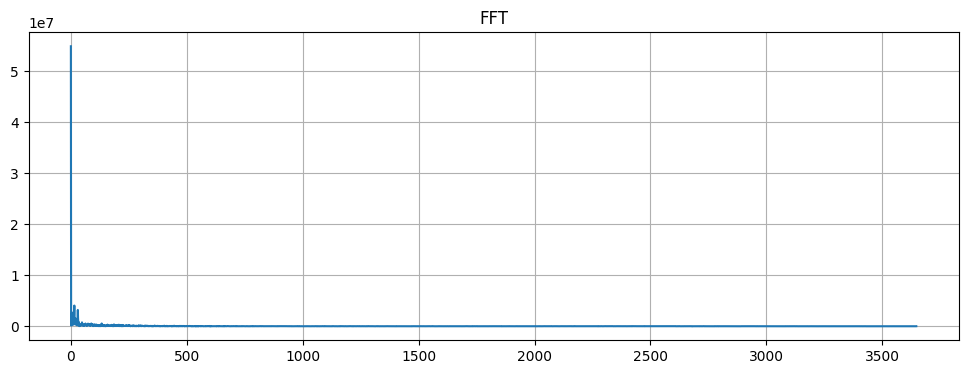

In [13]:
from scipy.fft import fft

fft_values = np.abs(fft(signal))

plt.figure(figsize=(12,4))

plt.plot(
    fft_values[:len(fft_values)//2]
)

plt.title("FFT")

plt.grid()

plt.show()